In [1]:
import icechunk
import matplotlib.pyplot as plt
import zarr

from srm import catalog
from srm.downscaling_utils import interpolate_fine_to_coarse_grid, rechunk
from srm.qaqc import (
    disagg_test_calculate_metrics,
)
from srm.utils import open_icechunk

## Get data

In [2]:
path_output = (
    # "s3://carbonplan-srm/output/production/CESM2-WACCM-ERA5-global.icechunk"
    "s3://carbonplan-scratch/srm/output/qa/CESM2-WACCM-ERA5-lat-35.0to-22.0_lon16.0to33.0.icechunk/"
)
path_qaqc = "/scratch/synced/qa_plots/disagg_checks/"
var = "tas"
scenario = "historical"
ens = "r3i1p1f1"
branch = "qa-qc-downscaling-step/vtest01"  # "v0.10.0" #

In [ ]:
storage = icechunk.s3_storage(
    bucket="carbonplan-scratch",  # "carbonplan-srm",
    prefix="srm/output/qa/CESM2-WACCM-ERA5-lat-35.0to-22.0_lon16.0to33.0.icechunk/",
    # "output/production/CESM2-WACCM-ERA5-global.icechunk/",
    region="us-west-2",
)
repo = icechunk.Repository.open(storage)
print(repo.list_branches())
session = repo.readonly_session(branch=branch)
root = zarr.open_group(session.store, mode="r")
print(root.tree())

In [4]:
coarse_debiased = open_icechunk(
    path=path_output,
    branch=branch,
    group="debiased_coarse/" + scenario + "/" + var + "/" + ens,
)[var]

debiased_downscaled = open_icechunk(
    path=path_output,
    branch=branch,
    group=scenario + "/" + var + "/" + ens,
)[var]

In [5]:
obs_fine = catalog.get("ERA5").to_xarray()[var]
obs_fine = obs_fine.where(obs_fine["time.year"] >= 1978, drop=True)
obs_fine_subset = obs_fine.sel(lat=slice(-35, -22), lon=slice(16, 33))

obs_fine = rechunk(obs_fine_subset, pattern="full_space").persist()
obs_coarse = interpolate_fine_to_coarse_grid(
    da_fine_to_coarsen=obs_fine, da_coarse_grid=coarse_debiased
).compute()

coarse_debiased = rechunk(coarse_debiased, pattern="full_space").persist()
coarse_debiased_finegrid = coarse_debiased.interp(
    lon=obs_fine["lon"],
    lat=obs_fine["lat"],
    method="nearest",
).compute()

fine = rechunk(
    debiased_downscaled, pattern="full_space"
).persist()  # -> (time≈25, lat=-1, lon=-1), ~100 MB/chunk
coarsened_debiased_downscaled = interpolate_fine_to_coarse_grid(
    da_fine_to_coarsen=fine, da_coarse_grid=coarse_debiased
)

# Compare some regridding options

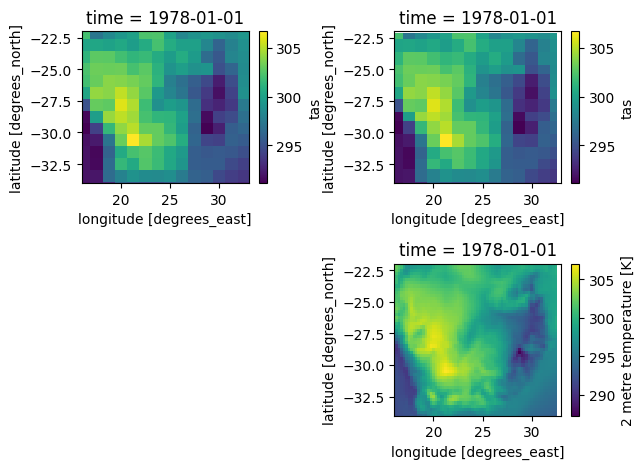

In [6]:
plt.subplot(2, 2, 1)
coarse_debiased.isel(time=0).plot()
plt.ylim([-34, -22])
plt.xlim([16, 33])

plt.subplot(2, 2, 2)
coarse_debiased_finegrid.isel(time=0).plot()
plt.ylim([-34, -22])
plt.xlim([16, 33])

plt.subplot(2, 2, 4)
debiased_downscaled.isel(time=0).plot()
plt.ylim([-34, -22])
plt.xlim([16, 33])
plt.tight_layout()

# Do evaluation

In [7]:
# Two outputs on fine grid
debiased_downscaled_doy = debiased_downscaled.groupby("time.dayofyear").mean().compute()
coarse_debiased_finegrid_doy = coarse_debiased_finegrid.groupby("time.dayofyear").mean().compute()

# Two outputs on coarse grid
coarse_debiased_doy = coarse_debiased.groupby("time.dayofyear").mean().compute()
coarsened_debiased_downscaled_doy = (
    coarsened_debiased_downscaled.groupby("time.dayofyear").mean().compute()
)

In [9]:
obs_fine_doy = obs_fine_subset.groupby("time.dayofyear").mean().compute()
obs_coarse_doy = obs_coarse.groupby("time.dayofyear").mean().compute()

In [10]:
metrics_obsfine_outputfine = disagg_test_calculate_metrics(
    x=obs_fine_doy, y=debiased_downscaled_doy, time_dim="dayofyear"
)
metrics_obsfine_outputcoarse = disagg_test_calculate_metrics(
    x=obs_fine_doy, y=coarse_debiased_finegrid_doy, time_dim="dayofyear"
)

metrics_obscoarse_outputfine = disagg_test_calculate_metrics(
    x=obs_coarse_doy, y=coarsened_debiased_downscaled_doy, time_dim="dayofyear"
)
metrics_obscoarse_outputcoarse = disagg_test_calculate_metrics(
    x=obs_coarse_doy, y=coarse_debiased_doy, time_dim="dayofyear"
)

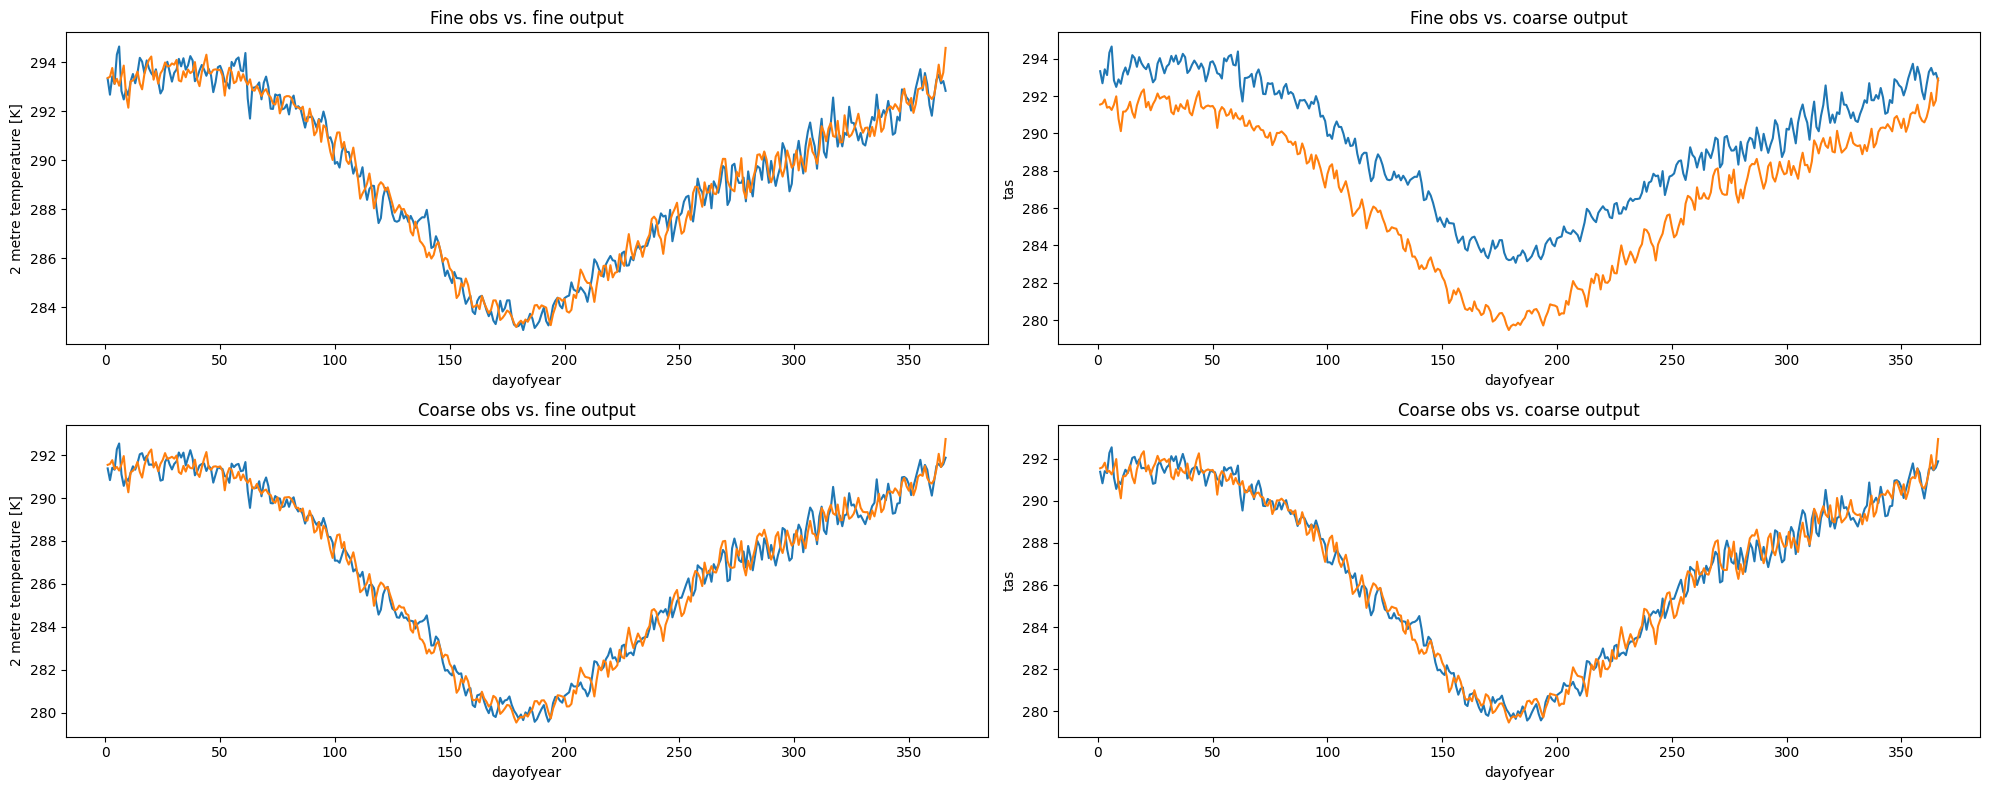

In [12]:
pt_lat = -31
pt_lon = 29
plt.figure(figsize=(20, 8))
plt.subplot(2, 2, 1)
(obs_fine_doy.sel(lat=pt_lat, lon=pt_lon).plot())
(debiased_downscaled_doy.sel(lat=pt_lat, lon=pt_lon).plot())
plt.title("Fine obs vs. fine output")
plt.subplot(2, 2, 2)
(obs_fine_doy.sel(lat=pt_lat, lon=pt_lon).plot())
(coarse_debiased_finegrid_doy.sel(lat=pt_lat, lon=pt_lon).plot())
plt.title("Fine obs vs. coarse output")
plt.subplot(2, 2, 3)
(obs_coarse_doy.sel(lat=pt_lat, lon=pt_lon, method="nearest").plot())
(coarsened_debiased_downscaled_doy.sel(lat=pt_lat, lon=pt_lon, method="nearest").plot())
plt.title("Coarse obs vs. fine output")
plt.subplot(2, 2, 4)
(obs_coarse_doy.sel(lat=pt_lat, lon=pt_lon, method="nearest").plot())
(coarse_debiased_doy.sel(lat=pt_lat, lon=pt_lon, method="nearest").plot())
plt.title("Coarse obs vs. coarse output")
plt.tight_layout()

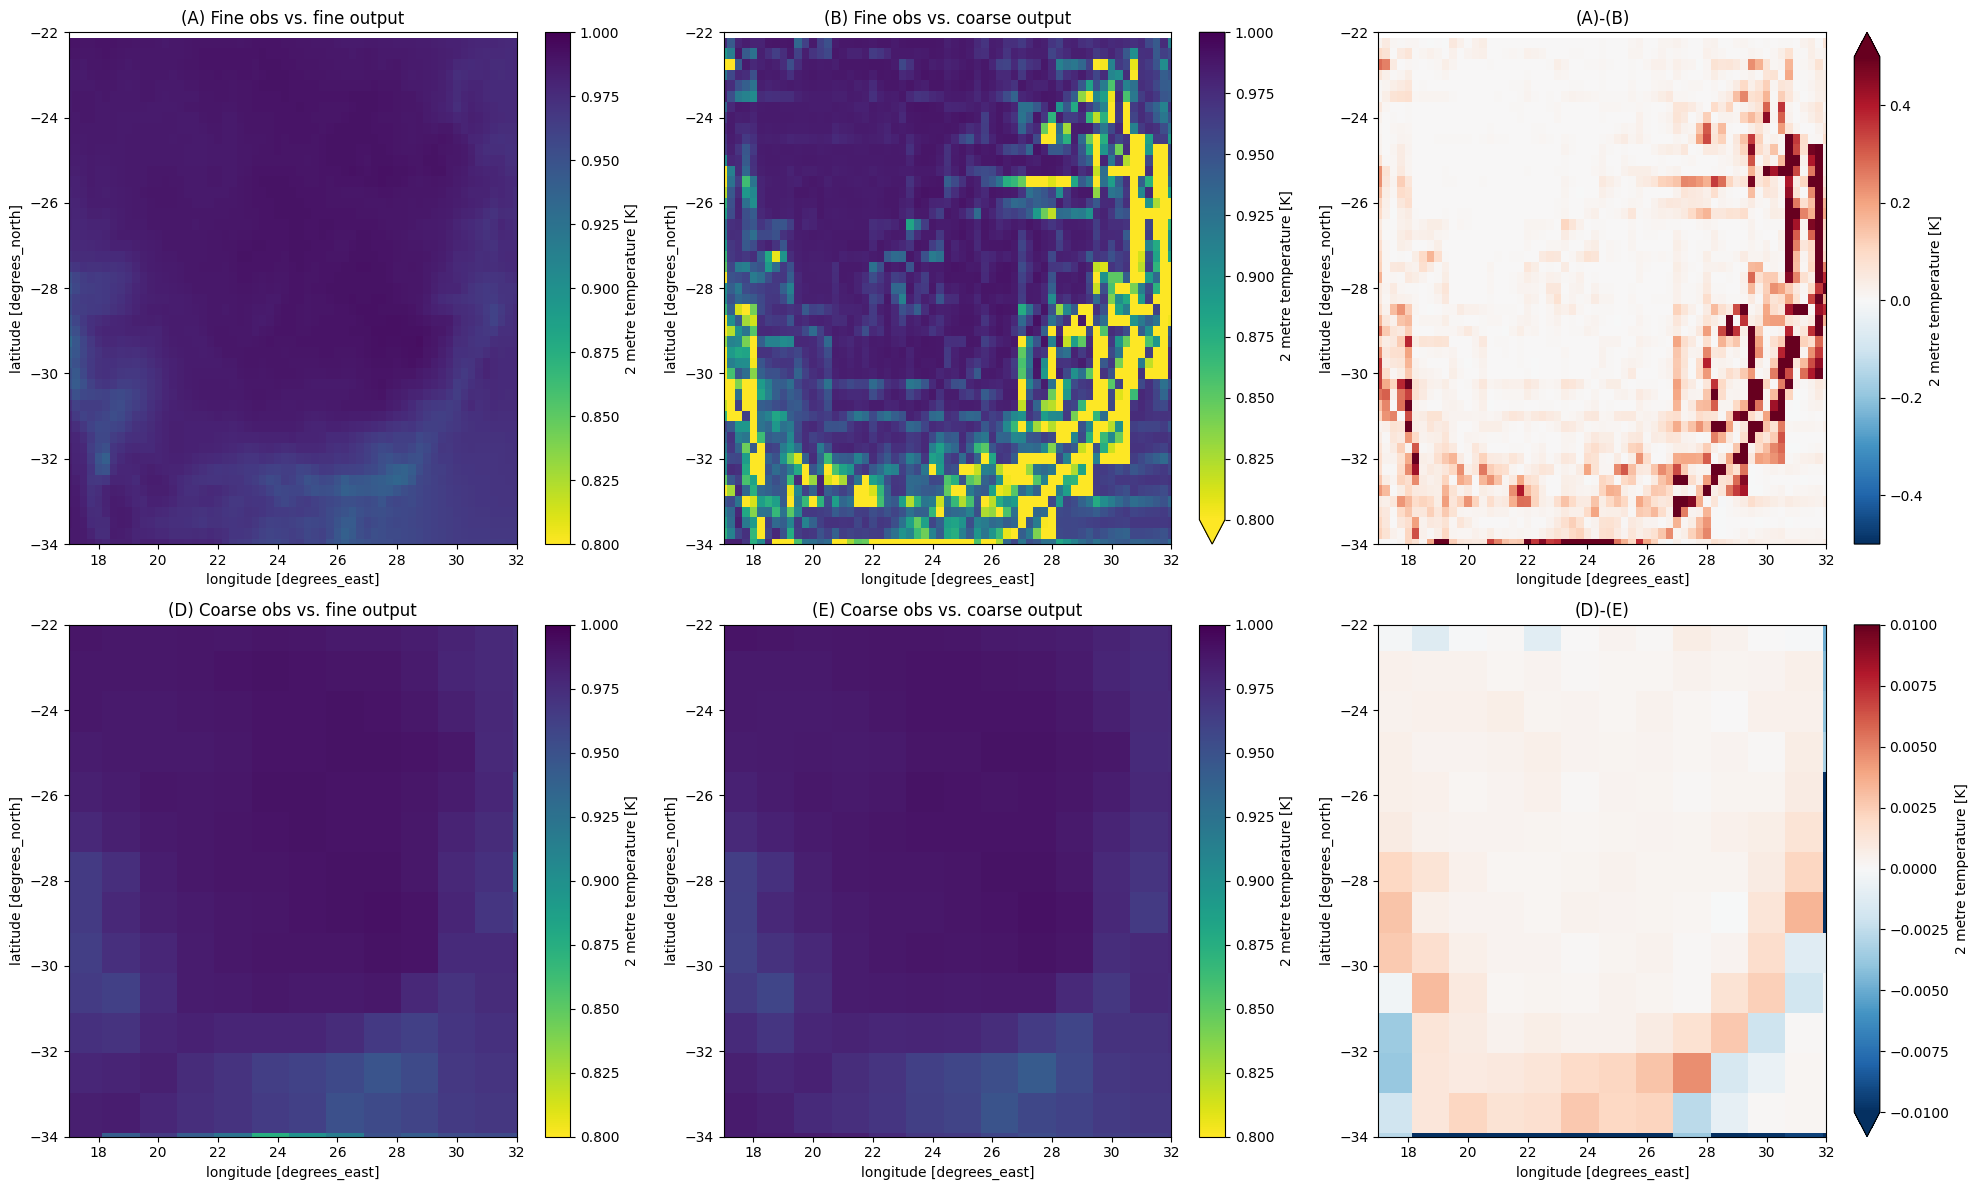

In [14]:
vmin = 0.8
vmax = 1


def format_subplot():
    plt.ylim([-34, -22])
    plt.xlim([17, 32])


plt.figure(figsize=(20, 12))
plt.subplot(2, 3, 1)
metrics_obsfine_outputfine["r2_oneone"].plot(vmax=vmax, vmin=vmin, cmap=plt.cm.viridis_r)
plt.title("(A) Fine obs vs. fine output")
format_subplot()
plt.subplot(2, 3, 2)
metrics_obsfine_outputcoarse["r2_oneone"].plot(vmax=vmax, vmin=vmin, cmap=plt.cm.viridis_r)
plt.title("(B) Fine obs vs. coarse output")
format_subplot()
plt.subplot(2, 3, 3)
(metrics_obsfine_outputfine["r2_oneone"] - metrics_obsfine_outputcoarse["r2_oneone"]).plot(vmax=0.5)
plt.title("(A)-(B)")
format_subplot()
plt.subplot(2, 3, 4)
metrics_obscoarse_outputfine["r2_oneone"].plot(vmax=vmax, vmin=vmin, cmap=plt.cm.viridis_r)
plt.title("(D) Coarse obs vs. fine output")
format_subplot()
plt.subplot(2, 3, 5)
metrics_obscoarse_outputcoarse["r2_oneone"].plot(vmax=vmax, vmin=vmin, cmap=plt.cm.viridis_r)
plt.title("(E) Coarse obs vs. coarse output")
format_subplot()
plt.subplot(2, 3, 6)
(metrics_obscoarse_outputfine["r2_oneone"] - metrics_obscoarse_outputcoarse["r2_oneone"]).plot(
    vmax=0.01
)
plt.title("(D)-(E)")
format_subplot()
plt.tight_layout()